In [1]:
import json
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors

In [2]:
RAW_PATH = Path("../data/raw/iowa_crash_data_raw.json")

with RAW_PATH.open("r", encoding="utf-8") as file:
    raw_data = json.load(file)

crashes = pd.DataFrame(
    feature["attributes"]
    for feature in raw_data["features"]
)

In [3]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,1421539200000,1421568000000,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,1422835200000,1422879480000,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,1423094400000,1423157100000,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,1422403200000,1422404160000,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,1423008000000,1423035300000,28,DELAWARE,5.0,1,1


In [4]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

In [5]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,2015-01-18,2015-01-18 08:00:00,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,2015-02-02,2015-02-02 12:18:00,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,2015-02-05,2015-02-05 17:25:00,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,2015-01-28,2015-01-28 00:16:00,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,2015-02-04,2015-02-04 07:35:00,28,DELAWARE,5.0,1,1


In [6]:
crashes.describe()

,OBJECTID,CRASH_KEY,CRASH_DATETIME,COUNTY_NUMBER,CSEV,WEATHER,CSRFCND
count,6.296030e+05,6.296030e+05,629603,629603.000000,629602.000000,629603.000000,629603.000000
mean,1.991306e+07,1.862379e+10,2020-10-01 07:30:05.252000,58.260062,4.568972,10.999484,10.580755
min,8.931903e+06,2.015836e+09,2015-01-01 00:13:00,0.000000,1.000000,1.000000,1.000000
25%,1.963688e+07,2.017102e+10,2017-11-10 17:23:30,32.000000,4.000000,1.000000,1.000000
50%,1.979428e+07,2.020119e+10,2020-09-22 17:00:00,64.000000,5.000000,1.000000,1.000000
75%,1.995168e+07,2.023138e+10,2023-08-31 23:52:30,78.000000,5.000000,2.000000,2.000000
max,2.544227e+07,2.026156e+10,2026-08-27 15:46:00,99.000000,5.000000,99.000000,99.000000
std,3.960329e+06,5.130475e+09,NaN,27.329521,0.792146,25.008862,24.713771


In [33]:
crashes.shape

(629603, 9)

In [56]:
crashes.columns

Index(['OBJECTID', 'CRASH_KEY', 'CRASH_DATE', 'CRASH_DATETIME',
       'COUNTY_NUMBER', 'COUNTY_NAME', 'CSEV', 'WEATHER', 'CSRFCND'],
      dtype='str')

In [54]:
print("OBJECTID unique:", crashes["OBJECTID"].is_unique)
print("Duplicated OBJECTIDs:", crashes["OBJECTID"].duplicated().sum())

OBJECTID unique: True
Duplicated OBJECTIDs: 0


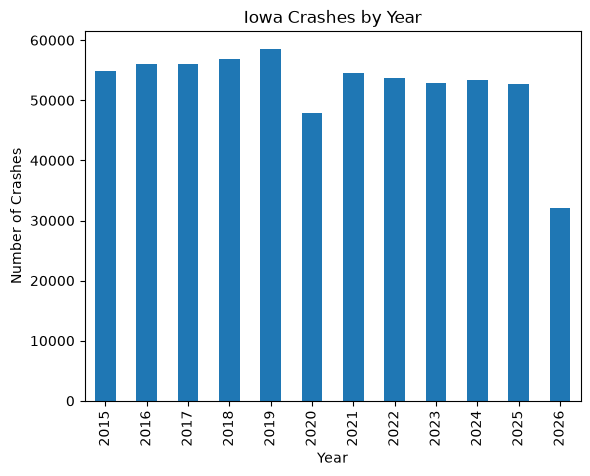

In [45]:
year_counts = crashes["CRASH_DATE"].dt.year.value_counts().sort_index()

year_counts.plot(
    kind="bar",
    xlabel="Year",
    ylabel="Number of Crashes",
    title="Iowa Crashes by Year"
)

plt.show()

In [7]:
print(crashes.isna().sum())
print(
    (
        (crashes["COUNTY_NUMBER"] == 0)
        & crashes["COUNTY_NAME"].isna()
    ).sum()
)


OBJECTID             0
CRASH_KEY            0
CRASH_DATE           0
CRASH_DATETIME       0
COUNTY_NUMBER        0
COUNTY_NAME       1118
CSEV                 1
WEATHER              0
CSRFCND              0
dtype: int64
1118


In [32]:
crashes[crashes["CSEV"].isna()]

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
501765,24527866,2.025147e+10,2025-03-12,2025-03-12 22:26:00,77,POLK,NaN,1,1


In [34]:
crashes_clean = crashes.dropna().copy()

In [9]:
crashes_grouped = crashes_clean.groupby("CRASH_DATE").count()

crashes["CRASH_DATE"] = pd.to_datetime(crashes["CRASH_DATE"])

monthly_crashes = (
    crashes
    .set_index("CRASH_DATE")
    .resample("MS")
    .size()
)

In [10]:
monthly_crashes.head()

CRASH_DATE
2015-01-01    5268
2015-02-01    4425
2015-03-01    3679
2015-04-01    3680
2015-05-01    4327
Freq: MS, dtype: int64

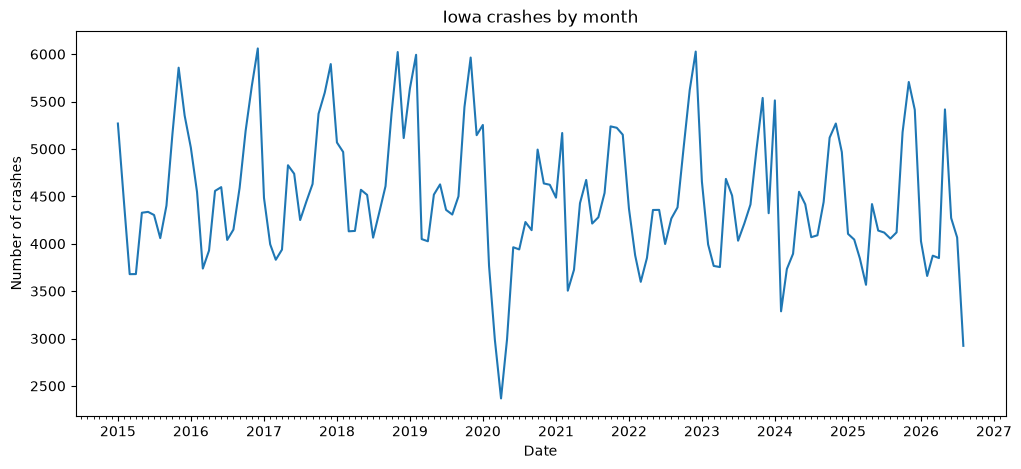

In [11]:
fig, ax = plt.subplots(figsize=(12,5))


ax.plot(monthly_crashes.index, monthly_crashes.values)

ax.set_title("Iowa crashes by month")
ax.set_xlabel("Date")
ax.set_ylabel("Number of crashes")

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.xaxis.set_minor_locator(mdates.MonthLocator())


plt.show()

In [12]:
crashes_v1 = crashes[
    (crashes["CRASH_DATETIME"] >= "2015-01-01") &
    (crashes["CRASH_DATETIME"] < "2026-01-01")
].copy()

crashes_v1["DATE"] = crashes_v1["CRASH_DATETIME"].dt.normalize()

crashes_v1["TIME_BLOCK"] = (
    crashes_v1["CRASH_DATETIME"].dt.hour // 3
)

BLOCK_LABELS = {
    0: "00:00–02:59",
    1: "03:00–05:59",
    2: "06:00–08:59",
    3: "09:00–11:59",
    4: "12:00–14:59",
    5: "15:00–17:59",
    6: "18:00–20:59",
    7: "21:00–23:59",
}

crashes_v1["TIME_BLOCK_LABEL"] = (
    crashes_v1["TIME_BLOCK"].map(BLOCK_LABELS)
)

In [13]:
crash_counts = (
    crashes_v1
    .groupby(
        ["COUNTY_NUMBER", "COUNTY_NAME", "DATE", "TIME_BLOCK"]
    )
    .size()
    .rename("crash_count")
    .reset_index()
)

In [14]:
crash_counts.head()

,COUNTY_NUMBER,COUNTY_NAME,DATE,TIME_BLOCK,crash_count
0,1,ADAIR,2015-01-05,4,3
1,1,ADAIR,2015-01-05,5,1
2,1,ADAIR,2015-01-06,2,2
3,1,ADAIR,2015-01-06,4,1
4,1,ADAIR,2015-01-09,6,1


In [15]:
counties = (
    crashes_v1[
        ["COUNTY_NUMBER", "COUNTY_NAME"]
    ]
    .drop_duplicates()
    .sort_values("COUNTY_NUMBER")
)

dates = pd.date_range(
    "2015-01-01",
    "2025-12-31",
    freq="D"
)

blocks = range(8)

In [16]:
full_index = pd.MultiIndex.from_product(
    [
        counties["COUNTY_NUMBER"],
        dates,
        blocks,
    ],
    names=["COUNTY_NUMBER", "DATE", "TIME_BLOCK"]
)

In [17]:
county_lookup = counties.set_index("COUNTY_NUMBER")["COUNTY_NAME"]

observed = (
    crash_counts
    .set_index(["COUNTY_NUMBER", "DATE", "TIME_BLOCK"])
    ["crash_count"]
)

county_block_data = (
    observed
    .reindex(full_index, fill_value = 0)
    .rename("crash_count")
    .reset_index()
)

county_block_data["COUNTY_NAME"] = (
    county_block_data["COUNTY_NUMBER"].map(county_lookup)
)

In [18]:
print(county_block_data.shape)
print(99 * len(dates) * 8)


(3214400, 5)
3182256


In [19]:
distribution = (
    county_block_data["crash_count"]
    .value_counts()
    .sort_index()
    .rename_axis("crash_count")
    .to_frame("observations")
)

distribution["percent"] = (
    distribution["observations"]
    / len(county_block_data)
    * 100
)

distribution.head(10)

,observations,percent
crash_count,,
0,2826509,87.932709
1,289905,9.018946
2,56251,1.749969
3,19389,0.603192
4,8656,0.269288
5,4695,0.146061
6,2810,0.087419
7,1855,0.057709
8,1161,0.036119


In [20]:
print(
    f"Zero crashes: ",
    f"{round((county_block_data["crash_count"] == 0).mean()*100, 2)}%"
)

print(
    f"Exactly one crash: "
    f"{round((county_block_data["crash_count"] == 1).mean()*100, 2)}%"
)

print(
    f"Two or more crashes: ",
    f"{round((county_block_data["crash_count"] >= 2).mean()*100, 2)}%"
)

Zero crashes:  87.93%
Exactly one crash: 9.02%
Two or more crashes:  3.05%


In [21]:
result = (
    county_block_data
    .groupby(["COUNTY_NUMBER", "TIME_BLOCK"])["crash_count"]
    .mean()
    .sort_values(ascending = False)
)

print(result.head(10))

COUNTY_NUMBER  TIME_BLOCK
77             5             7.824042
               4             5.194126
               2             3.964410
               3             3.737183
               6             3.654555
82             5             2.510204
57             5             2.402190
77             7             2.085117
82             4             1.898457
52             5             1.766551
Name: crash_count, dtype: float64


In [22]:
print(result.tail(10))

COUNTY_NUMBER  TIME_BLOCK
95             0             0.004978
2              1             0.002489
0              7             0.000000
               6             0.000000
               5             0.000000
               4             0.000000
               3             0.000000
               2             0.000000
               1             0.000000
               0             0.000000
Name: crash_count, dtype: float64


In [23]:
county_daily = (
    county_block_data
    .groupby(
        ["COUNTY_NUMBER", "COUNTY_NAME", "DATE"],
        as_index=False 
    )["crash_count"]
    .sum()
)

county_daily_mean = (
    county_daily
    .groupby("COUNTY_NAME")["crash_count"]
    .mean()
    .sort_values()
)

In [24]:
county_daily_mean.head()

COUNTY_NAME
ADAMS        0.102041
RINGGOLD     0.129667
WINNEBAGO    0.144599
TAYLOR       0.153310
WAYNE        0.157790
Name: crash_count, dtype: float64

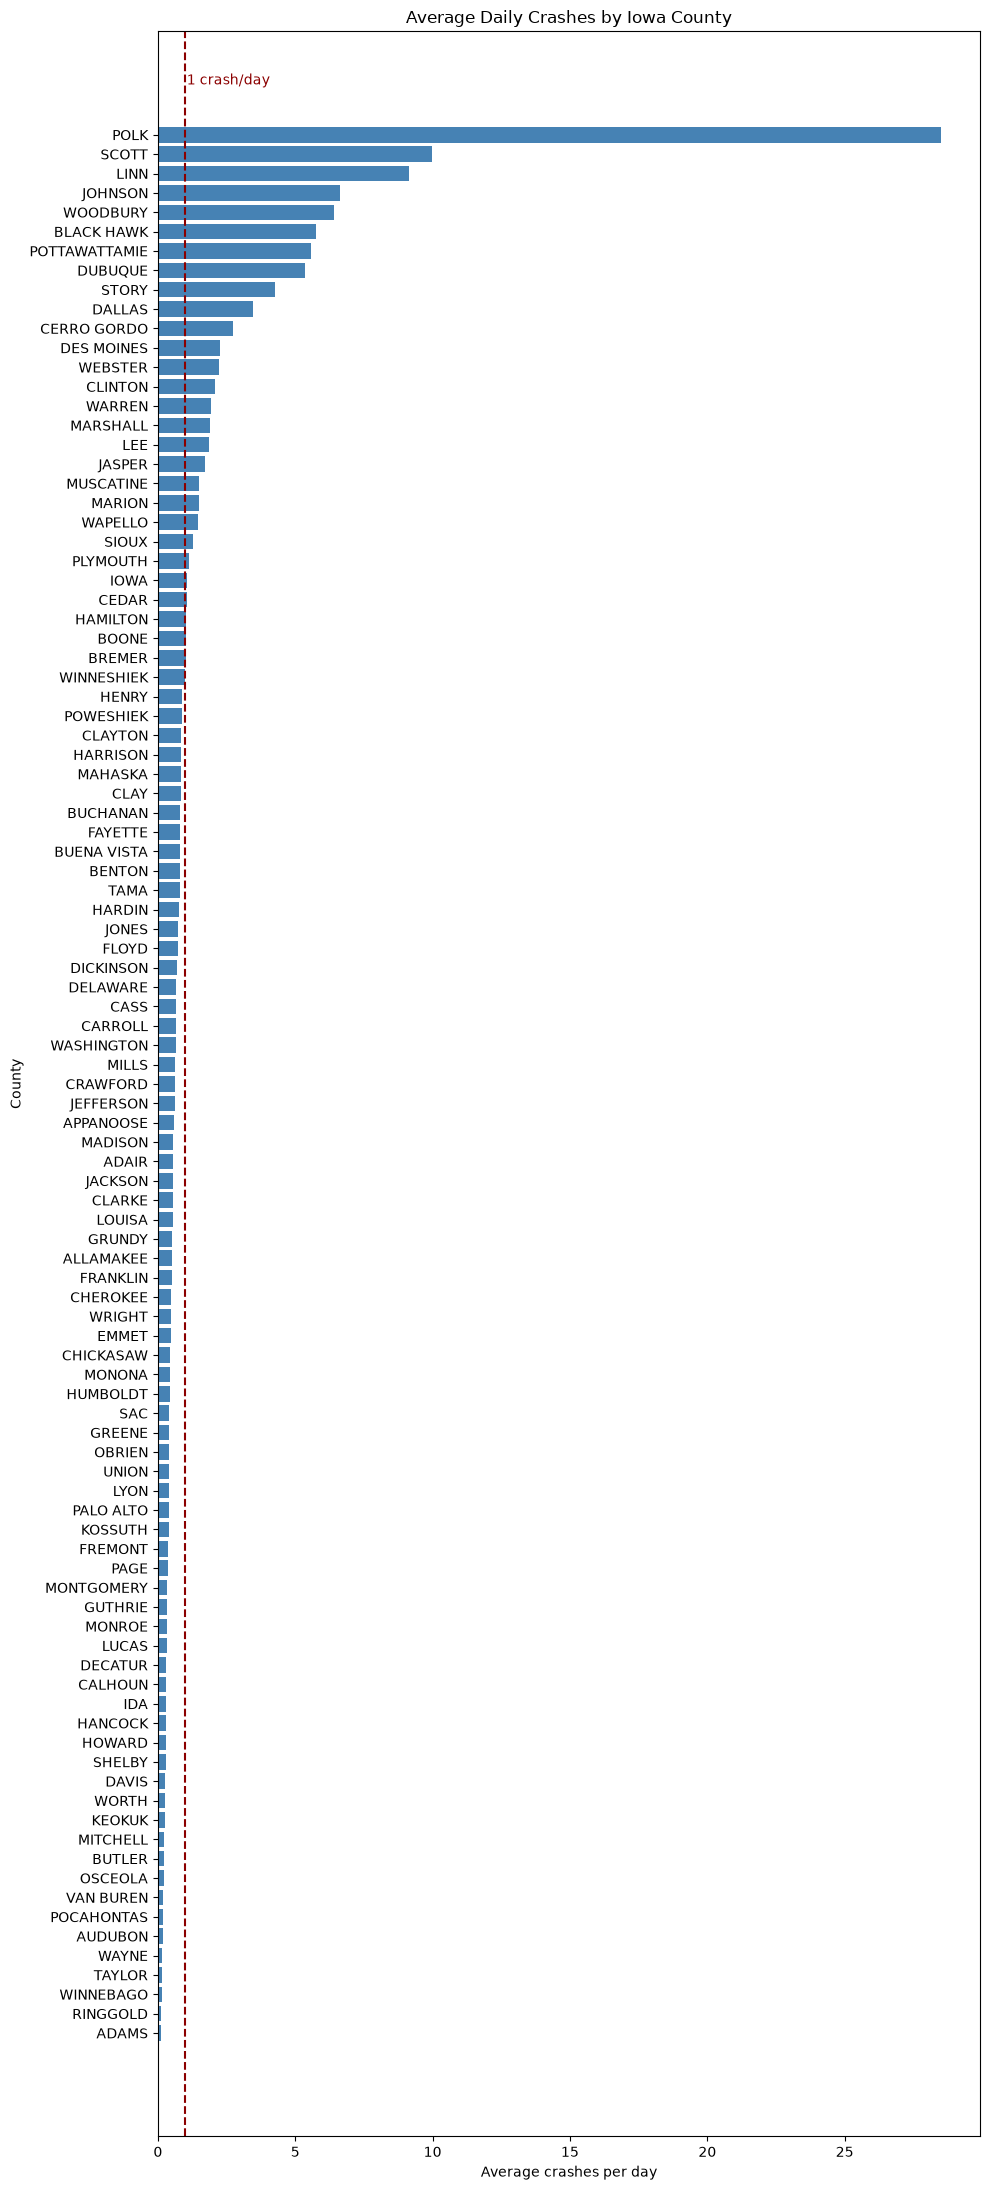

In [25]:
fig, ax = plt.subplots(figsize =(10,22))

ax.barh(
    county_daily_mean.index,
    county_daily_mean.values,
    color="steelblue"
)

ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1.5,
    color = "darkred"
)

ax.text(
    1.05,
    0.98,
    "1 crash/day",
    transform=ax.get_xaxis_transform(),
    va="top",
    color="darkred"
)

ax.set_title("Average Daily Crashes by Iowa County")
ax.set_xlabel("Average crashes per day")
ax.set_ylabel("County")

plt.tight_layout()
plt.show()

In [26]:
block_means = (
    county_block_data
    .groupby(
        ["COUNTY_NUMBER", "COUNTY_NAME", "TIME_BLOCK"],
        as_index=False
    )["crash_count"]
    .mean()
)

In [27]:
county_order = (
    block_means
    .groupby("COUNTY_NAME")["crash_count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

In [28]:
heatmap_data = block_means.pivot(
    index="COUNTY_NAME",
    columns="TIME_BLOCK",
    values="crash_count"
)

heatmap_data = heatmap_data.loc[county_order]

In [29]:
heatmap_data.shape

(99, 8)

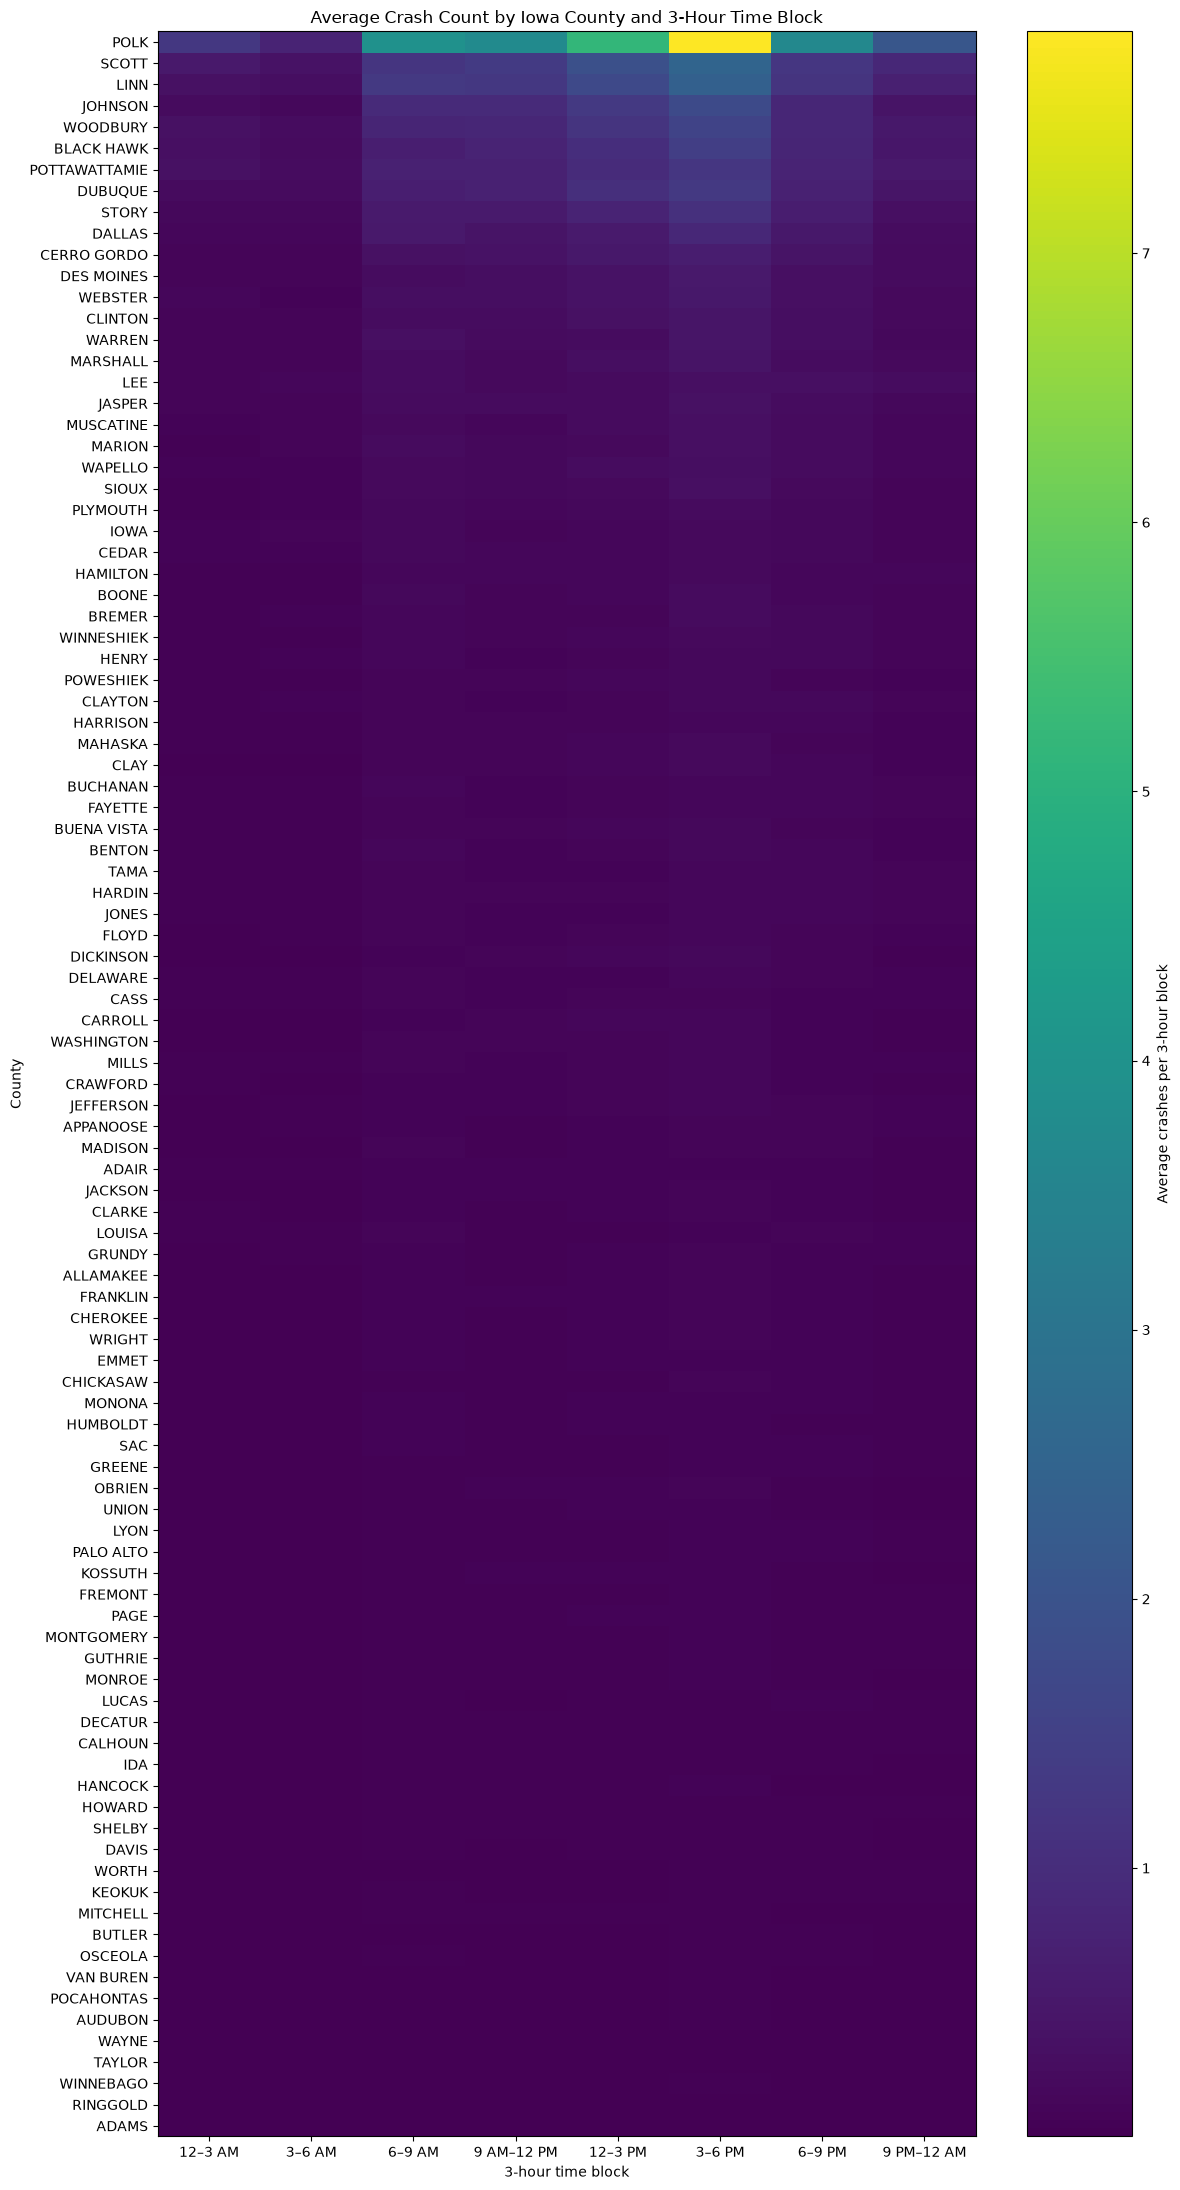

In [30]:
fig, ax = plt.subplots(figsize=(12,22))

image = ax.imshow(
    heatmap_data,
    aspect="auto"
)

ax.set_title("Average Crash Count by Iowa County and 3-Hour Time Block")

ax.set_xlabel("3-hour time block")
ax.set_ylabel("County")

ax.set_xticks(range(8))

ax.set_xticklabels([
    "12–3 AM",
    "3–6 AM",
    "6–9 AM",
    "9 AM–12 PM",
    "12–3 PM",
    "3–6 PM",
    "6–9 PM",
    "9 PM–12 AM",
])

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

fig.colorbar(
    image,
    ax=ax,
    label="Average crashes per 3-hour block"
)

plt.tight_layout()
plt.show()

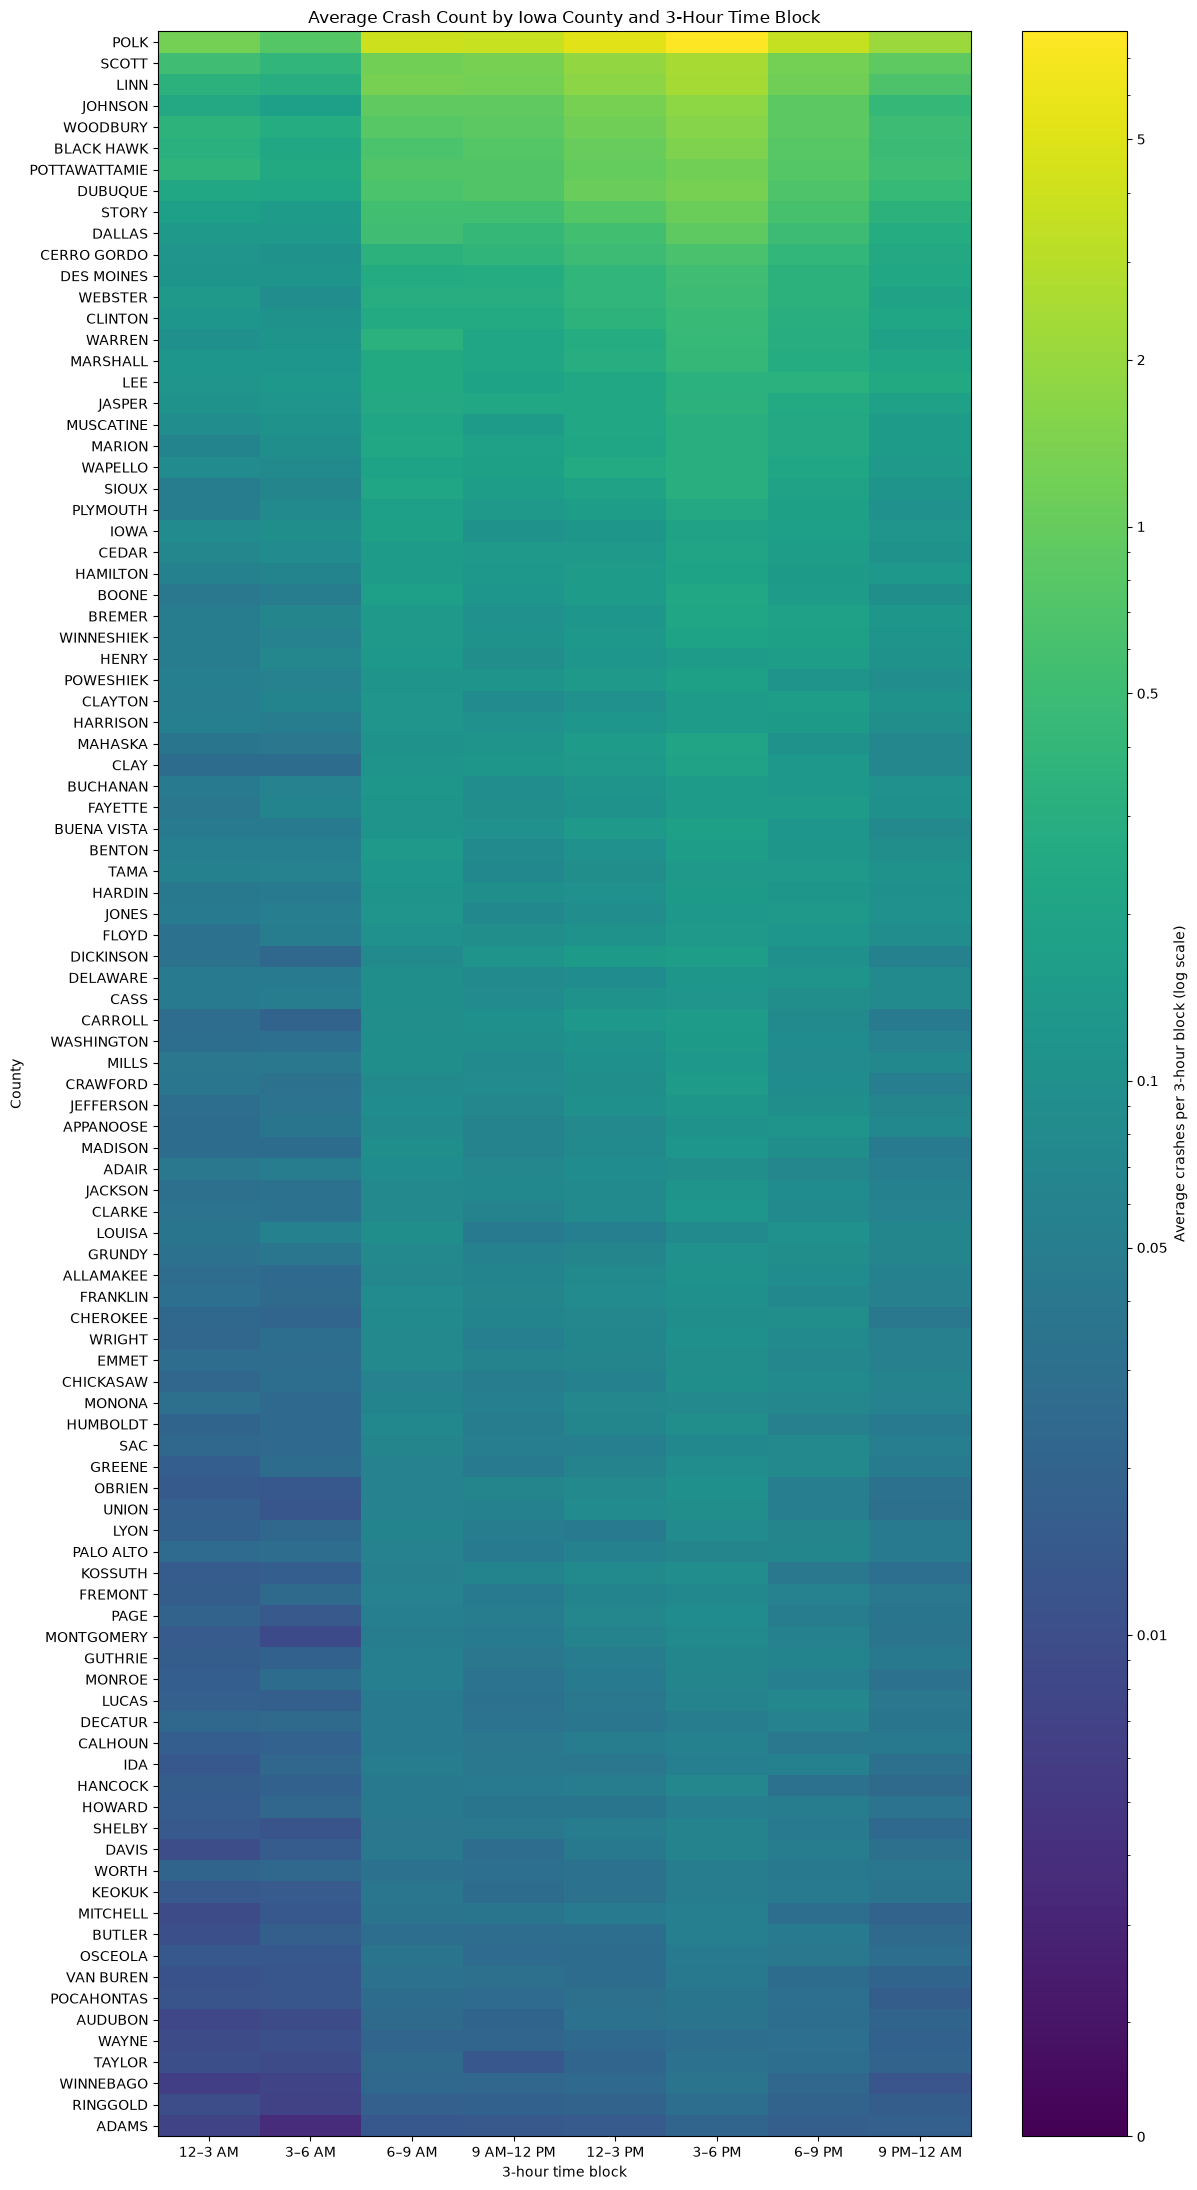

In [31]:
values = heatmap_data.to_numpy()

positive_min = values[values > 0].min()

epsilon = positive_min / 2

plot_values = values + epsilon

fig, ax = plt.subplots(figsize=(12,22))

image = ax.imshow(
    plot_values,
    aspect="auto",
    norm=colors.LogNorm(
        vmin=epsilon,
        vmax=plot_values.max()
    )
)

ax.set_title("Average Crash Count by Iowa County and 3-Hour Time Block")
ax.set_xlabel("3-hour time block")
ax.set_ylabel("County")

ax.set_xticks(range(8))
ax.set_xticklabels([
    "12–3 AM",
    "3–6 AM",
    "6–9 AM",
    "9 AM–12 PM",
    "12–3 PM",
    "3–6 PM",
    "6–9 PM",
    "9 PM–12 AM",
])

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Average crashes per 3-hour block (log scale)")

tick_values = [epsilon, 0.01, 0.05, 0.1, 0.5, 1, 2, 5]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([
    "0",
    "0.01",
    "0.05",
    "0.1",
    "0.5",
    "1",
    "2",
    "5",
])

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd 


HOURLY_VARIABLES = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "wind_speed_10m",
    "precipitation",
    "weather_code",
    "wind_direction_10m",
]


weather = pd.read_parquet(
    "../data/raw/historical_weather/ia_hourly_weather_2016-01.parquet"
)

print(weather[HOURLY_VARIABLES].nunique())
print(weather[HOURLY_VARIABLES].isna().sum())

temperature_2m          23385
relative_humidity_2m    70251
pressure_msl              414
wind_speed_10m           2466
precipitation              23
weather_code               11
wind_direction_10m       7857
dtype: int64
temperature_2m          0
relative_humidity_2m    0
pressure_msl            0
wind_speed_10m          0
precipitation           0
weather_code            0
wind_direction_10m      0
dtype: int64
